# Overarching Exercise - The Bridge

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF
import scipy.stats



c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Design of a concrete bridge

This exercise will focus on the design of a concrete bridge, where the variable of interest will be the total weight of the vehicles. This dataset has been retrieved from the Weight-in-Motion system from the Netherlands, which measures a number of characteristics of heavily loaded traffic in certain locations throughout the country. These are speed (km/h), vehicle length (m), load per axle (kN), and number of axles (-). As the probabilistic design engineer at your firm, you have been tasked with providing preliminary design parameters, which includes: defining the design values to be used for this design (Module I, defining boundary conditions); evaluating the reliability of the structure components (Module II, reliability analysis); and assessing the whole system reliability (Module III, risk assessment).

```{figure} ../figures/modules.png

---

---
Schematic description of the 3 modules of the exercise.

In [11]:
#lets load the data
loads = pd.read_csv('data\Overarching Exercise WIM Data.csv',header=None)

#### Dataset processing: daily maximum loads

:::{card} First, lets examine the statistics and distribution of the maximum daily loads. To do so, you need to set a high threshold to define which loads we consider as 'maximum'. Here, we are using the quantile function from numpy and the threshold is the 95th percentile (or 0.95 quantile). You can change the value and see yourself what happens.

In [12]:
# Select random values
threshold = np.quantile(loads, 0.95)
N_data = len(loads)

# Sample maxima with threshold
W = loads[loads > threshold]

## dropping annoying NaN's
W = W.dropna()
W_t = W - threshold

:::{card} Lets see now some characteristic values of the distribution of the maxima. Enter your code to see the minima, the maximum, the mean and the median and then the table will automatically be updated.

In [13]:
#enter your code here

minimum = np.min(np.array(W))
maximum = np.max(np.array(W))
mean = np.mean(np.array(W))
median = np.median(np.array(W))
mode = np.array(W.mode()[0][0])
std = np.std(np.array(W))

```{admonition} Solution
:class: tip, dropdown
This is only one way to calculate the above:

<code>minimum = np.min(np.array(W))</code>

<code>maximum = np.max(np.array(W))</code>

<code>mean = np.mean(np.array(W))</code>

<code>median = np.median(np.array(W))</code>

<code>mode = np.array(W.mode()[0][0])</code>

<code>std = np.std(np.array(W))</code>

```

Run the cell bellow after you fill the code above!

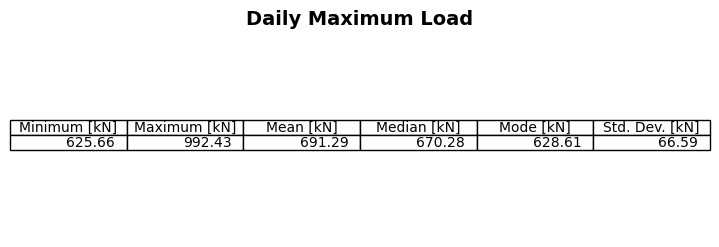

In [14]:
## code for making the table
columns = ['Minimum [kN]', 'Maximum [kN]', 'Mean [kN]', 'Median [kN]', 'Mode [kN]',
        'Std. Dev. [kN]']
data = [[f'{minimum:.2f}', f'{maximum:.2f}', 
         f'{mean:.2f}', f'{median:.2f}', 
         f'{mode:.2f}', f'{std:.2f}']]

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 3))  # You can adjust the figure size as needed

# Hide the axes
ax.xaxis.set_visible(False) 
ax.yaxis.set_visible(False)
ax.set_frame_on(False)

ax.set_title('Daily Maximum Load', fontsize=14, fontweight='bold')
# Create the table
table = ax.table(cellText=data, colLabels=columns, loc='center')

# Adjust cell sizes
table.auto_set_font_size(False)
table.set_fontsize(10)

# Adjust the scaling of the cells
table.scale(1, 1)  # Scale width by 2 and height by 2 (you can adjust these values)

# Adjust layout
plt.subplots_adjust(left=0.2, bottom=0.2)

# Show the table
plt.show()

:::{card} What does this information tell you about the daily maximum load on the bridge? Is the data set skewed? Plot or sketch a histogram of the data. What is the typical load you would expect on a single day? Why?

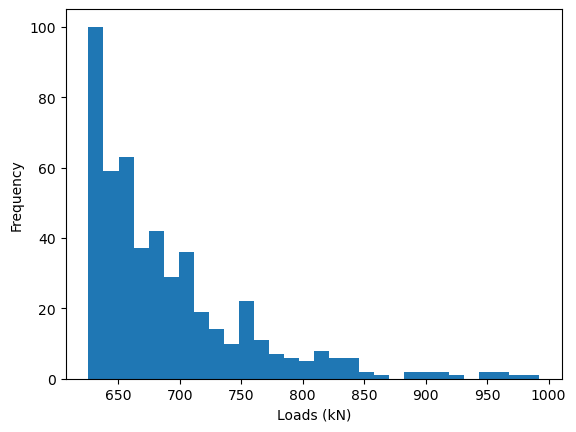

In [6]:
plt.hist(W,bins=30);
plt.xlabel('Loads (kN)')
plt.ylabel('Frequency')
plt.show()

:::{card} Rank the data and determine the empirical CDF for daily maximum load.

C:\Users\chari\AppData\Local\Temp\ipykernel_36836\2945195173.py:15: RuntimeWarning: divide by zero encountered in log
  plt.step(x0, np.log(f0), linewidth=1.5, label='Empirical CDF (Full Data)')
C:\Users\chari\AppData\Local\Temp\ipykernel_36836\2945195173.py:18: RuntimeWarning: divide by zero encountered in log10
  plt.step(x + threshold, np.log10(f), linewidth=1.5, label='Empirical CDF (Thresholded)')


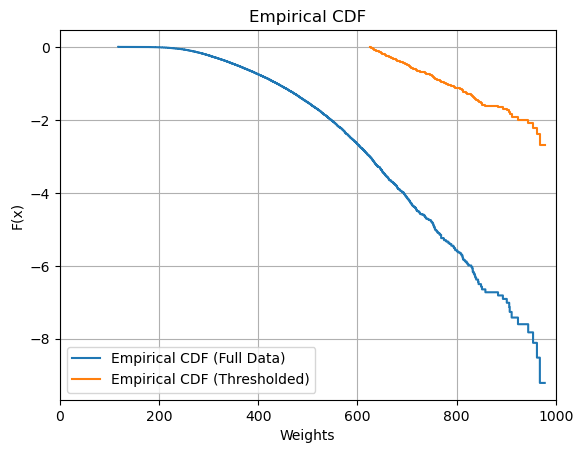

In [7]:
# Empirical Complementary CDF
ecdf_full = ECDF(np.array(loads).flatten())
[f0, x0] = 1 - ecdf_full.y, ecdf_full.x

# Thresholded Complementary Empirical CDF
ecdf_thresh = ECDF(np.array(W_t).flatten())
[f, x] = 1 - ecdf_thresh.y, ecdf_thresh.x

# Plot empirical CDF
plt.figure()
plt.title('Empirical CDF')
plt.xlim([0, 1000])

# Plot full data CDF using the plt.step function
plt.step(x0, np.log(f0), linewidth=1.5, label='Empirical CDF (Full Data)')

# Uncomment the next lines to include the thresholded CDF
plt.step(x + threshold, np.log10(f), linewidth=1.5, label='Empirical CDF (Thresholded)')

plt.xlabel('Weights')
plt.ylabel('F(x)')
plt.legend()
plt.grid(True)
plt.show()


:::{card} Choose a parametric probability distribution model to fit the daily maximum load data – this will allow you to assess the relative frequency of the daily maxima, as well as make an assessment on rarer events (you can use scipy.stats.<distribution> to do so by replacing <distribution> by the distribution type you want to fit ).

Shape: 0.923914853709892, Location: 0.9800000000000181, Scale: 60.58726445153576


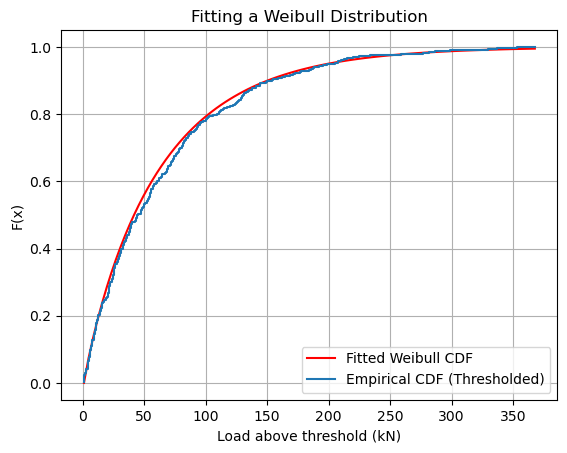

In [8]:
shape, loc, scale = scipy.stats.weibull_min.fit(np.array(W_t))  # Shape, location, and scale parameters
print(f"Shape: {shape}, Location: {loc}, Scale: {scale}")

# Generate the fitted PDF
x_weib = np.linspace(min(np.array(W_t)), max(np.array(W_t)), 100)
cdf = scipy.stats.weibull_min.cdf(x_weib, c=shape, loc=loc, scale=scale)

# Plot the data and fitted Weibull CDF

plt.plot(x_weib, cdf, label="Fitted Weibull CDF", color="red")

plt.grid()
plt.title("Fitting a Weibull Distribution")

# Plot full data CDF
plt.step(x, 1 - f, linewidth=1.5, label='Empirical CDF (Thresholded)')
plt.legend()
plt.ylabel('F(x)')
plt.xlabel('Load above threshold (kN)')
plt.show()

```{admonition} Solution
:class: tip, dropdown

Fitting a Weibull distribution to the loads data:

<code> shape, loc, scale = scipy.stats.weibull_min.fit(np.array(W_t))  # Shape, location, and scale parameters </code> 

<code> print(f"Shape: {shape}, Location: {loc}, Scale: {scale}") </code> 

<code> # Generate the fitted PDF </code> 

<code> x_weib = np.linspace(min(np.array(W_t)), max(np.array(W_t)), 100) </code> 

<code> cdf = scipy.stats.weibull_min.cdf(x_weib, c=shape, loc=loc, scale=scale) </code> 

<code> # Plot the data and fitted Weibull CDF </code>

<code> plt.plot(x_weib, cdf, label="Fitted Weibull CDF", color="red") </code> 

<code> plt.grid() </code> 

<code> plt.title("Fitting a Weibull Distribution") </code> 

<code> # Plot full data CDF </code>

<code> plt.step(x, 1 - f, linewidth=1.5, label='Empirical CDF (Thresholded)') </code> 

<code> plt.legend() </code>

<code> plt.ylabel('F(x)') </code> 

<code> plt.xlabel('Load above threshold (kN)') </code> 

<code> plt.show() </code> 
```

:::{card} Plot the empirical CDF and theoretical CDF as exceedance probability (i.e., 1-F(x)) with the vertical axis in log scale while trying some different distributions. Comment on the differences or similarities: how do they compare for load values above 800 kN? How do they compare below 800 kN? Which criteria are used to compare different distributions? How would you choose the best one? 

Weibull Shape: 0.923914853709892, Location: 0.9800000000000181, Scale: 60.58726445153576
Gamma Shape: 0.8335020965094762, Location: 0.980000000000018, Scale: 76.72444163971329


C:\Users\chari\AppData\Local\Temp\ipykernel_36836\1996259835.py:20: RuntimeWarning: divide by zero encountered in log10
  plt.step(x, np.log10(f), linewidth=1.5, label='Empirical CDF (Thresholded)')


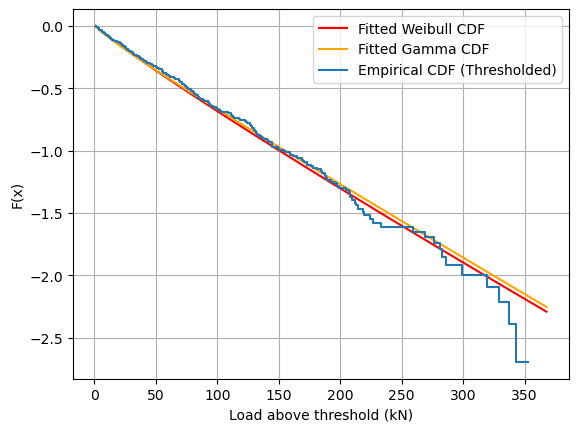

In [9]:
x_fit = np.linspace(min(np.array(W_t)), max(np.array(W_t)), 100)

# Generate the fitted Weibull
shape, loc, scale = scipy.stats.weibull_min.fit(np.array(W_t))  # Shape, location, and scale parameters
print(f"Weibull Shape: {shape}, Location: {loc}, Scale: {scale}")
cdf_weib = scipy.stats.weibull_min.cdf(x_fit, c=shape, loc=loc, scale=scale)

# Plot the data and fitted Weibull CDF
plt.plot(x_fit, np.log10(1- cdf_weib), label="Fitted Weibull CDF", color="red")

##gamma distribution
shape, loc, scale = scipy.stats.gamma.fit(np.array(W_t))  # Shape, location, and scale parameters
print(f"Gamma Shape: {shape}, Location: {loc}, Scale: {scale}")
cdf_gamma = scipy.stats.gamma.cdf(x_fit, a=shape, loc=loc, scale=scale)

# Plot the data and fitted Gamma CDF
plt.plot(x_fit, np.log10(1- cdf_gamma), label="Fitted Gamma CDF", color="orange")

# Plot full data CDF
plt.step(x, np.log10(f), linewidth=1.5, label='Empirical CDF (Thresholded)')


plt.legend()
plt.grid()
plt.ylabel('F(x)')
plt.xlabel('Load above threshold (kN)')
plt.show()

```{admonition} Solution
:class: tip, dropdown

Fitting a Weibull distribution to the loads data:

<code>x_fit = np.linspace(min(np.array(W_t)), max(np.array(W_t)), 100)</code>

<code># Generate the fitted Weibull</code>

<code>shape, loc, scale = scipy.stats.weibull_min.fit(np.array(W_t))  # Shape, location, and scale parameters</code>

<code>print(f"Weibull Shape: {shape}, Location: {loc}, Scale: {scale}")</code>

<code>cdf_weib = scipy.stats.weibull_min.cdf(x_fit, c=shape, loc=loc, scale=scale)</code>

<code># Plot the data and fitted Weibull CDF</code>

<code>plt.plot(x_fit, np.log10(1 - cdf_weib), label="Fitted Weibull CDF", color="red")</code>

<code>##gamma distribution</code>

<code>shape, loc, scale = scipy.stats.gamma.fit(np.array(W_t))  # Shape, location, and scale parameters</code>

<code>print(f"Gamma Shape: {shape}, Location: {loc}, Scale: {scale}")</code>

<code>cdf_gamma = scipy.stats.gamma.cdf(x_fit, a=shape, loc=loc, scale=scale)</code>

<code># Plot the data and fitted Gamma CDF</code>

<code>plt.plot(x_fit, np.log10(1 - cdf_gamma), label="Fitted Gamma CDF", color="orange")</code>

<code># Plot full data CDF</code>

<code>plt.step(x, np.log10(f), linewidth=1.5, label='Empirical CDF (Thresholded)')</code>

<code>plt.legend()</code>

<code>plt.grid()</code>

<code>plt.ylabel('F(x)')</code>

<code>plt.xlabel('Load above threshold (kN)')</code>

<code>plt.show()</code>
```

:::{card} From the distribution that best fits the data, find the value with an exceedance probability of $10^{-4}$. Tip: Remember than when using the peak over threshold sampling method, you have subtracted the threshold value from the variable.

In [10]:
# Your answer here

### Module II - Bridge Reliability

*In this module, we will use reliability analysis to design one component of the bridge (the beam). Keep in mind that while we will only look at a single load and bridge component, there are many parts of the bridge structure that could be analysed with reliability methods. The extreme value analysis from Module I is used for this module.* 

After completing your extreme value analysis in Module I, you have now been tasked with evaluating whether or not the preliminary beam design has enough capacity for an extreme event. More specifically, your task is to evaluate the probability that the beam fails by shear stresses. If the beam is not capable of supporting the shear forces exerted by the loads, it could lead to a complete bridge failure. 

The beam’s shear flexure capacity is given by the following equation: 

$V_u = C_0*k*(100*\rho_1*f_c)^{1/3}*b_w*d$

Where $C_0$ is a coefficient, $k$ is a size factor, $\rho_1$ is the longitudinal reinforcement ratio, $f_c$ is the concrete compressive strength, $b_w$ and $w$ are the cross-sectional dimensions of the beam. While considering 
 to follow a lognormal distribution with the parameters presented in Table 1, and assuming the other values as deterministic, the previous equation can be reduced to the following:

 $V_u = C*f_c^{1/3}$

 As we discovered in Module I, traffic loading is uncertain, as well as the concrete’s compressive strength. Using the equation above, we will evaluate the beam’s shear stress resistance reliability by using Level III and Level II methods for two random variables ($f_c$ and traffic load $W$). We are interested in finding the annual probability of failure, which in this case is the probability that annual maximum load exceeds the shear resistance of the beam.  

Consider the following deterministic values for the preliminary design: 

<ul>
    <math>C_0 = 4.5</math>
    <li><math>\rho_1 = 0.01</math></li>
    <li><math>b_w = 10</math></li>
    <li><math>d = 5.8</math></li>
    <li><math>k = 1 + \sqrt{\frac{200}{d}}</math></li>
</ul>



:::{card} Fill the table below with the values you ended up with in Module I. 

<div align="center">

**Table 1**

| **Variable**       | **Distribution** | **Mean** | **Std. Dev.** | **λ**   | **ζ**   |
|---------------------|------------------|----------|---------------|---------|---------|
| $f [kg/cm^2]$      | Lognormal        | 255      | 65            | 5.5     | 0.25    |
| $ W_n $            | Weibull          |          |               |         |         |

</div>


```{note}
If your answer to question 5 in Module 1 isn’t approximately 1200, then revisit your fitted distributions. 
```

#### Part A - Limit-state function and random variables

:::{card} How does the shear capacity of the preliminary design above compare to the daily maxima data set from Module I (i.e., the values in Table 1)? Is it higher or lower than the maximum value observed? Is it higher than the mean value? How many standard deviations away from the mean is $W$? Based on these characteristics, what is your initial guess for how reliable the bridge is? Is it likely or unlikely that it will fail? What would you guess is the probability of failure? 

In [ ]:
# your answer here

```{admonition} Solution
:class: tip, dropdown

Assuming $f_c$ = 255 and $R = 1137.41$:
- 6.7std's away from the mean
- $P(-6.7\sigma) = 1.44e^{11}$
```

:::{card}
Formulate the limit-state function, $g(V_u,W)$, for the beam using the equation for $V_u$ above. Use $W_0$ to represent axle load. Recall that “failure” is defined as $g(V_u,W)$≤0, which in this case is a function of two random variables, $V_u$ and $W$.

In [ ]:
#your answer here

```{admonition} Solution
:class: tip, dropdown

$Z = C*f_{c}^{\frac{1}{3}} - W$
```

:::{card} Create a plot of the beam limit-state in terms of $V_u$ and $W$.
 
.

In [ ]:
#your answer here

:::{card} Add the following to your previous plot for $V_u$ and $W$: a) mean values, b) median values, and c) probability density contours for the bivariate PDF. 

```{note}
You can sketch the contours by hand to visualize them. For a bivariate (i.e., 2-variable) normal distribution with equal variance for each variable, contours will be concentric circles. If the variance of one variable is larger than the other, contours will be concentric ellipsoids with a long axis parallel to the higher variance axis. For non-normal distributions contours will no longer by symmetric along the axis parallel to the non-normal variable. It is also important to remember that for non-symmetric distributions the mean is no longer the same as the mode.
```

#### Part B - Level III, Crude Monte Carlo

:::{card} Use crude Monte Carlo sampling to estimate the failure probability for the beam, using the probability distribution in Table 1 and the one found in Module 1. After using only N = 1000 samples, what is the estimated failure probability? What is the coefficient of variation (V) for the computed failure probability (see lecture notes Section 5.4.1)? Add these values to Table 2.

:::{card} Now repeat the Monte Carlo simulation with N = 10,000 samples. Fill the remaining row in Table 2. Based on the results in Table 2, do you think your estimate of failure probability is stable? Why?

<div align="center">

**Table 2 – Crude Monte Carlo Results**

| **N**     | **Number of Failures** | **Estimated $p_f$** | **V**  |
|-----------|-------------------------|---------------------|--------|
| 1,000     |                       |                |     |
| 10,000    |                       |              |     |
| 100,000   |                      |              |    |

</div>


:::{card} Based on the results from Table 2, what can you say about the number of simulations executed in a Monte Carlo simulation to compute the probability of failure? When is convergence reached?

In [ ]:
#your answer here

```{admonition} Solution
:class: tip, dropdown

An increased number of simulations increases the accuracy of the estimated probability of failure by reducing its coefficient of variation. Convergence is not quite reached with 10,000 simulations, highlighting the downside of using Monte Carlo in the increased computational time required.

```

:::{card} 
Take your plot from Part A and add the random samples. Do the samples match your computed (or sketched) probability contours? Do the number of failed and non-failed scenarios match your estimated failure probability?

#### Part C

*Although you will be checking your FORM results using Prob2B in Part D, you are encouraged to perform the calculations in this part by hand, as this is one of the critical skills required for the exam.*

:::{card} Now use the First Order Reliability Method (FORM) to find the design point for the beam (the “second method” discussed in lecture and the lecture notes). Fill in Table 3 with the first 3 steps of your iteration, and Table 4 with the final result once your solution has stabilized.

<div align="center">

**Table 3 – FORM Iterations**

|                | **Initial Value** | **Iteration 1** | **Iteration 2** | **Iteration 3** | **...** |
|----------------|-------------------|-----------------|-----------------|-----------------|---------|
| $\sigma_z$     | -                 |                 |                 |                 |         |
| $\mu_z$        | -                 |                 |                 |                 |         |
| $\beta$        | -                 |                 |                 |                 |         |
| $\alpha_{v_u}$ | -                 |                 |                 |                 |         |
| $\alpha_w$     | -                 |                 |                 |                 |         |
| $V_u^*$        |                   |                 |                 |                 |         |
| $W^*$          |                   |                 |                 |                 |         |

</div>


<div align="center">

**Table 4 – FORM Results**
| **β** | **$p_f$** | **Design Point, x*** | **Importance, $a_i$** |
|-------------------|-----------------|-----------------|-----------------|
|                  |                 |     $V_u*$ =             |   $a_{vu}$ =           | 
|                  |                 |     $W*$   =             |   $a_{w}$  =              |

</div>

:::{card} Take your plot from Part A (without the Monte Carlo realizations from Part B) and add the following features from the FORM analysis.

<ul>
    <li> Design point, Vu* and W*</li>
    <li> Linearized limit-state function (illustrate which side is failure)</li>
    <li> Reliability index, β</li>
    <li> Distance αi βσi for each random variables</li>
</ul>



```{note}
Although you could plot these features in the software you are using, simply sketching them should also be sufficient to illustrate your understanding of the concepts. 
```

:::{card} . Based on your FORM results, which variable has the most influence on beam reliability? How do the values of the design point compare to the design values selected for the deterministic analysis? Do you think the beam capacity is high enough? Make a suggestion for improving the design

In [ ]:
#your answer here

#### Part D - Confirm with Prob2B and Dependence

### Module III - Risk Assessment

*In this module, we will develop a risk assessment of the bridge system components. In the previous modules, we’ve analysed the probability of failure of a beam for one failure mechanism (shear). However, a system is composed of many components which must be taken into account for a complete system reliability analysis.*

Now that the beam’s failure probability due to shear has been computed, you now have the task to evaluate the reliability of the entire bridge system. For this computation, we will consider ‘bending’ as an additional failure mechanism of the beam, this probability of failure has been computed and presented in Table 5. Furthermore, the bridge system is detailed in the following picture:


In [ ]:
#insert drawing here

As can be seen, each deck span consists of 2 beams and the system is known to fail when the deck fails by fatigue or both of the beams fail by shear . For the questions in this module assume the probabilities of failure described in the following table:

<div align="center">

**Table 5: Probability of failure of other components.**
| **Component** | **Failure Mechanism** | **$P_f$*** | 
|-------------------|-----------------|-----------------|-----------------|
|                  |                 |     $V_u*$ =             |   $a_{vu}$ =           | 
|                  |                 |     $W*$   =             |   $a_{w}$  =              |

</div>

#### Part A – System Reliability Analysis

:::{card} Using the information provided and by means of the given drawing, elaborate the fault tree which corresponds to this case. 

```{figure} ../figures/reliability_analysis.png

---

---
Fault tree.

:::{card} Compute the failure probability of the system assuming full independence between the components (Hint: refer to section 9.4 of the lecture notes) and compare the corresponding reliability index to the ones stipulated in the Eurocode (CC2).  Does the system comply with the safety requirements? Based only the influence of the failure probability of each element, what would be the most efficient to ensure the system meets the requirements?

#Your answer here

```{admonition} Solution
:class: tip, dropdown

$P_f(system) = 1 - (1 - P_f(span))^n$, n = number of spans
$P_f(span) = 1 - (1 - P_f(deck))*(1 - P_f(2 beams))$
$P_f(2 beams) = P_f(beam 1)*P_f(beam 2)$
$P_f(beam) = 1 - (1 - P_f(shear))*(1 - P_f(bending))$
$P_f(system) = 5.27*10^{-4}$
$P_f(required) = 10^{-4}$

```


#### Part B - System failure bounds

In reality, dependence between the different components of the system can be expected, for this section we will analyze the effects of this dependence on the failure probability of the system.


:::{card} Give the Ditlevsen bounds for computed failure probability of the system, assuming the coefficient of correlation between the beams is $ρ = 0.7$.

#Your answer here

```{admonition} Solution
:class: tip, dropdown

For $P_f(2 beams)$:

$\beta = -P_f(beam) = 2.83$
$\beta^* = \frac{\beta - \rho\beta}{\sqrt{1-rho^2}}$
$Lower bound = \phi(-\beta)*\phi(-\beta^*) = 2.74^{-4}$
$Upper bound = 2\phi(-\beta)*\phi(-\beta^*) = 5.48^{-4}$

For $P_f(system)$:

Lower bound = 0.00187
Upper bound = 0.00324

```

#### Part C - Risk Analysis

:::{card} Given a probability of dying given failure of $P{d|f} = 10^{-2}$, estimate the allowable probability of failure of the system. (Hint: Use the concept of acceptable individual risk and justify your recommendation; there isn’t necessarily a “right” answer)

#Your answer here

```{admonition} Solution
:class: tip, dropdown

$IR_{acc} = 10^{-5}$
$P_{facc} = \frac{IR_{acc}}{P_{d|f}} = 0.001$

```

:::{card} Construct the FN curve corresponding to the bridge system. Plot the limit line while considering a risk neutral and a risk aversion stance. Consider the following plausible scenarios:

a)	Failure of 1 beam = 50 deaths

b)	Failure of 2 beams = 500 deaths

c)	Failure of deck = 100 deaths


In [ ]:
#Your answer here